# Argentina vs France — 2022 FIFA World Cup Final

## Ball Progression and Chance Creation Analysis

This project analyzes how Argentina progressed the ball and created scoring opportunities against France in the 2022 FIFA World Cup Final.

Using StatsBomb Open Data, the analysis focuses on:

- Shot production and chance quality
- Progressive passing
- Ball progression from center-backs
- Progressive passing connections
- Final-third entries
- Chance creation after entering the final third

The objective is to identify the main patterns behind Argentina's progression and attacking production during the match.


In [1]:
%pip install -q statsbombpy mplsoccer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 3.2 MB/s eta 0:00:00


In [2]:
from statsbombpy import sb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mplsoccer import Pitch, VerticalPitch

from matplotlib.lines import Line2D

## Data

The analysis uses StatsBomb Open Data from the 2022 FIFA World Cup.

Match:
**Argentina vs France — FIFA World Cup Final**

StatsBomb match ID: `3869685`

StatsBomb uses a 120 x 80 coordinate system, where the attacking goal is centered approximately at `(120, 40)`.

In [3]:
match_id = 3869685

events = sb.events(match_id=match_id)

# 1. Shot Profile

Before analyzing Argentina's ball progression, we first look at the overall attacking output of both teams.

The objective is to compare:

- Shot volume
- Shot locations
- Expected Goals (xG)
- Goals scored

In [4]:
match_shots = events.loc[
    (events['type'] == 'Shot') &
    (events['period'] != 5)
    ].copy()

match_shots['team'].value_counts()

,count
team,
Argentina,20
France,10


In [5]:
match_shots['x'] = match_shots['location'].apply(lambda loc:loc[0])
match_shots['y'] = match_shots['location'].apply(lambda loc:loc[1])
match_shots['is_goal'] = match_shots['shot_outcome'] == 'Goal'

match_shots[
    ['team', 'location', 'x', 'y', 'shot_statsbomb_xg', 'shot_outcome', 'is_goal']
].head()

,team,location,x,y,shot_statsbomb_xg,shot_outcome,is_goal
4207,Argentina,"[92.4, 30.0]",92.4,30.0,0.024542,Saved,False
4208,Argentina,"[99.2, 47.9]",99.2,47.9,0.062813,Blocked,False
4209,Argentina,"[103.1, 34.6]",103.1,34.6,0.106801,Off T,False
4210,Argentina,"[108.0, 40.0]",108.0,40.0,0.783500,Goal,True
4211,Argentina,"[94.3, 23.5]",94.3,23.5,0.010578,Wayward,False


In [6]:
argentina_shots = match_shots.loc[match_shots['team'] == 'Argentina'].copy()
france_shots = match_shots.loc[match_shots['team'] == 'France'].copy()

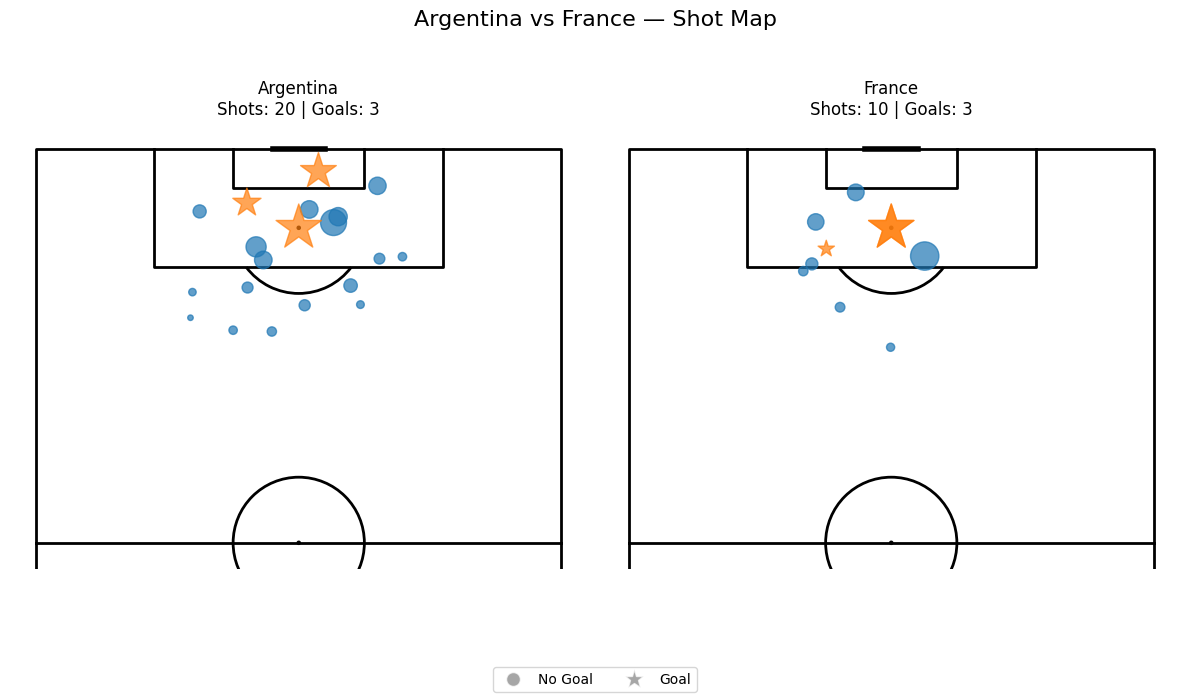

In [7]:
from mplsoccer import VerticalPitch
import matplotlib.pyplot as plt

pitch = VerticalPitch(
    pitch_type='statsbomb',
    half=True,
    line_color='black'
)

fig, axs = pitch.draw(nrows=1, ncols=2, figsize=(12, 7))

# ---------- ARGENTINA ----------
argentina_goals = argentina_shots.loc[argentina_shots['is_goal'] == True]
argentina_no_goals = argentina_shots.loc[argentina_shots['is_goal'] == False]

pitch.scatter(
    argentina_no_goals['x'],
    argentina_no_goals['y'],
    s=argentina_no_goals['shot_statsbomb_xg'] * 1500,
    alpha=0.7,
    ax=axs[0]
)

pitch.scatter(
    argentina_goals['x'],
    argentina_goals['y'],
    s=argentina_goals['shot_statsbomb_xg'] * 1500,
    marker='*',
    alpha=0.7,
    ax=axs[0]
)

axs[0].set_title('Argentina Shots')


# ---------- FRANCE ----------
france_goals = france_shots.loc[france_shots['is_goal'] == True]
france_no_goals = france_shots.loc[france_shots['is_goal'] == False]

pitch.scatter(
    france_no_goals['x'],
    france_no_goals['y'],
    s=france_no_goals['shot_statsbomb_xg'] * 1500,
    alpha=0.7,
    ax=axs[1]
)

pitch.scatter(
    france_goals['x'],
    france_goals['y'],
    s=france_goals['shot_statsbomb_xg'] * 1500,
    marker='*',
    alpha=0.7,
    ax=axs[1]
)

axs[1].set_title('France Shots')

# ---------- LEYENDA ----------
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='No Goal',
           markerfacecolor='gray', markersize=10, alpha=0.7),
    Line2D([0], [0], marker='*', color='w', label='Goal',
           markerfacecolor='gray', markersize=14, alpha=0.7)
]

fig.legend(handles=legend_elements, loc='lower center', ncol=2)
plt.tight_layout()
fig.suptitle(
    'Argentina vs France — Shot Map',
    fontsize=16,
    y=0.98
)
axs[0].set_title(
    f'Argentina\nShots: {len(argentina_shots)} | Goals: {len(argentina_goals)}'
)

axs[1].set_title(
    f'France\nShots: {len(france_shots)} | Goals: {len(france_goals)}'
)
plt.show()


### Key takeaway

Argentina produced a higher volume of shots than France and generated more non-penalty attacking opportunities throughout the match.

# 2. Ball Progression from the Back

After examining the teams' shot production, the analysis now focuses on how Argentina progressed the ball from deeper areas.

Particular attention is given to the center-backs, after observing that Cristian Romero was one of Argentina's main progressive passers despite Nicolás Otamendi completing more passes overall.

In [8]:
passes= events.loc[events.type=='Pass'].copy()
passes['pass_complete'] = passes['pass_outcome'].isna()
completed_passes_map = passes.loc[passes['pass_complete'] == True].copy()
completed_passes_map['x_start'] = completed_passes_map['location'].apply(lambda loc:loc[0])
completed_passes_map['y_start'] = completed_passes_map['location'].apply(lambda loc:loc[1])
completed_passes_map['x_end'] = completed_passes_map['pass_end_location'].apply(lambda loc:loc[0])
completed_passes_map['y_end'] = completed_passes_map['pass_end_location'].apply(lambda loc:loc[1])
completed_passes_map['goal_distance_start'] = np.sqrt((120 - completed_passes_map['x_start'])**2 +
                                                      (40- completed_passes_map['y_start'])**2)
completed_passes_map['goal_distance_end'] = np.sqrt((120 - completed_passes_map['x_end'])**2 +
                                                      (40- completed_passes_map['y_end'])**2)
completed_passes_map['goal_distance_reduction']= (completed_passes_map['goal_distance_start']) - (completed_passes_map['goal_distance_end'])
completed_passes_map['is_progressive'] = (completed_passes_map['goal_distance_reduction'] >= 10)
completed_passes_map[
    ['team',
     'player',
     'position',
     'pass_recipient',
     'x_start',
     'y_start',
     'x_end',
     'y_end',
     'goal_distance_start',
     'goal_distance_end',
     'goal_distance_reduction',
     'is_progressive']

]

,team,player,position,pass_recipient,x_start,y_start,x_end,y_end,goal_distance_start,goal_distance_end,goal_distance_reduction,is_progressive
12,France,Antoine Griezmann,Center Attacking Midfield,Aurélien Djani Tchouaméni,61.0,40.1,48.0,43.2,59.000085,72.071076,-13.070991,False
14,Argentina,Nahuel Molina Lucero,Right Back,Rodrigo Javier De Paul,22.7,80.0,36.0,75.2,105.201188,91.077110,14.124078,True
15,Argentina,Rodrigo Javier De Paul,Right Center Midfield,Cristian Gabriel Romero,41.1,73.9,23.2,62.8,85.874443,99.448881,-13.574438,False
16,Argentina,Cristian Gabriel Romero,Right Center Back,Nicolás Hernán Otamendi,24.7,59.4,21.5,32.2,97.254563,98.808350,-1.553787,False
17,Argentina,Nicolás Hernán Otamendi,Left Center Back,Cristian Gabriel Romero,24.0,27.1,21.7,49.3,96.862841,98.738949,-1.876108,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1268,Argentina,Enzo Fernandez,Right Center Midfield,Lionel Andrés Messi Cuccittini,42.8,54.1,58.0,62.4,78.477067,65.922379,12.554688,True
1269,Argentina,Lionel Andrés Messi Cuccittini,Right Center Forward,Gonzalo Ariel Montiel,66.8,62.6,104.9,62.6,57.801384,27.180324,30.621060,True
1270,Argentina,Gonzalo Ariel Montiel,Right Wing Back,Lautaro Javier Martínez,109.3,61.6,110.8,41.6,24.104979,9.338094,14.766885,True
1273,Argentina,Leandro Daniel Paredes,Center Defensive Midfield,Enzo Fernandez,47.1,27.3,56.1,22.0,73.997973,66.386821,7.611152,False


In [9]:
completed_passes_map.groupby('team')['is_progressive'].agg(['sum', 'count'])

,sum,count
team,,
Argentina,128,560
France,91,434


In [10]:
player_passing = completed_passes_map.groupby(['team','player', 'position'])['is_progressive'].agg(['count', 'sum', 'mean'])
player_passing = player_passing.rename(columns={'count': 'completed_passes', 'sum': 'progressive_passes', 'mean': 'progressive_passes_pct'})
player_passing['progressive_passes_pct'] = player_passing['progressive_passes_pct'] * 100
player_passing = player_passing.reset_index()
player_passing = player_passing.sort_values(by='progressive_passes', ascending=False)
player_passing

,team,player,position,completed_passes,progressive_passes,progressive_passes_pct
1,Argentina,Cristian Gabriel Romero,Right Center Back,60,24,40.000000
27,France,Hugo Lloris,Goalkeeper,23,19,82.608696
29,France,Jules Koundé,Right Back,52,15,28.846154
16,Argentina,Nahuel Molina Lucero,Right Back,39,14,35.897436
13,Argentina,Lionel Andrés Messi Cuccittini,Right Wing,48,14,29.166667
41,France,Raphaël Varane,Right Center Back,55,12,21.818182
17,Argentina,Nicolás Alejandro Tagliafico,Left Back,44,12,27.272727
3,Argentina,Enzo Fernandez,Center Defensive Midfield,66,10,15.151515
18,Argentina,Nicolás Hernán Otamendi,Left Center Back,69,9,13.043478
25,France,Dayotchanculle Upamecano,Left Center Back,51,9,17.647059


In [11]:
player_passing.loc[
    (player_passing['team'] == 'Argentina') &
    (player_passing['position'].str.contains('Center Back', na=False))
]

,team,player,position,completed_passes,progressive_passes,progressive_passes_pct
1,Argentina,Cristian Gabriel Romero,Right Center Back,60,24,40.000000
18,Argentina,Nicolás Hernán Otamendi,Left Center Back,69,9,13.043478
5,Argentina,Germán Alejandro Pezzella,Center Back,1,0,0.000000


In [12]:
argentina_cbs = player_passing.loc[
    (player_passing['team'] == 'Argentina') &
    (player_passing['position'].str.contains('Center Back', na=False)) &
    (player_passing['completed_passes'] >= 20)
].copy()

argentina_cbs

,team,player,position,completed_passes,progressive_passes,progressive_passes_pct
1,Argentina,Cristian Gabriel Romero,Right Center Back,60,24,40.000000
18,Argentina,Nicolás Hernán Otamendi,Left Center Back,69,9,13.043478


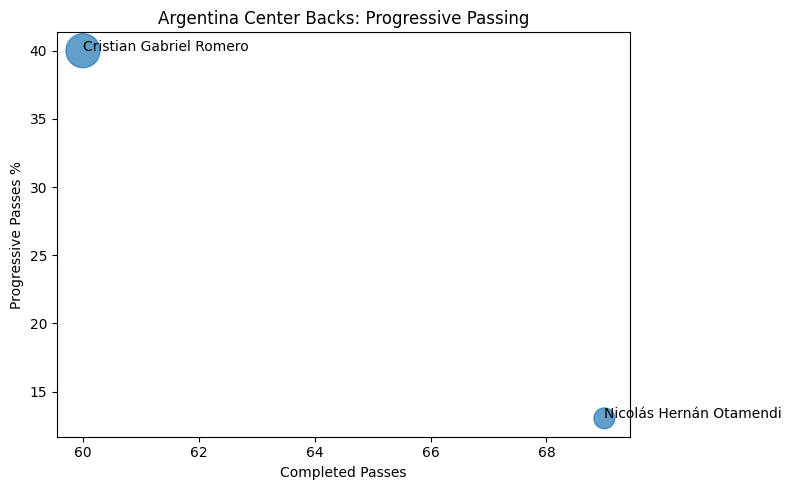

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(
    argentina_cbs['completed_passes'],
    argentina_cbs['progressive_passes_pct'],
    s=argentina_cbs['progressive_passes'] * 25,
    alpha=0.7
)

plt.xlabel('Completed Passes')
plt.ylabel('Progressive Passes %')
plt.title('Argentina Center Backs: Progressive Passing')

for _, row in argentina_cbs.iterrows():
    plt.annotate(
        row['player'],
        (row['completed_passes'], row['progressive_passes_pct'])
    )

plt.tight_layout()
plt.show()

### Center-back progression

Although Nicolás Otamendi completed more passes than Cristian Romero (69 vs 60),
Romero contributed much more frequently to territorial progression.

Romero completed 24 progressive passes, representing 40% of his completed passes,
while Otamendi completed 9 progressive passes (13%).

This suggests different roles in Argentina's build-up, which can be explored further
by examining the spatial distribution of their progressive passes.

In [14]:
romero_progressive = completed_passes_map.loc[
    (completed_passes_map['player'] == 'Cristian Gabriel Romero') &
    (completed_passes_map['is_progressive'] == True)
].copy()

otamendi_progressive = completed_passes_map.loc[
    (completed_passes_map['player'] == 'Nicolás Hernán Otamendi') &
    (completed_passes_map['is_progressive'] == True)
].copy()

In [15]:
len(romero_progressive), len(otamendi_progressive)

(24, 9)

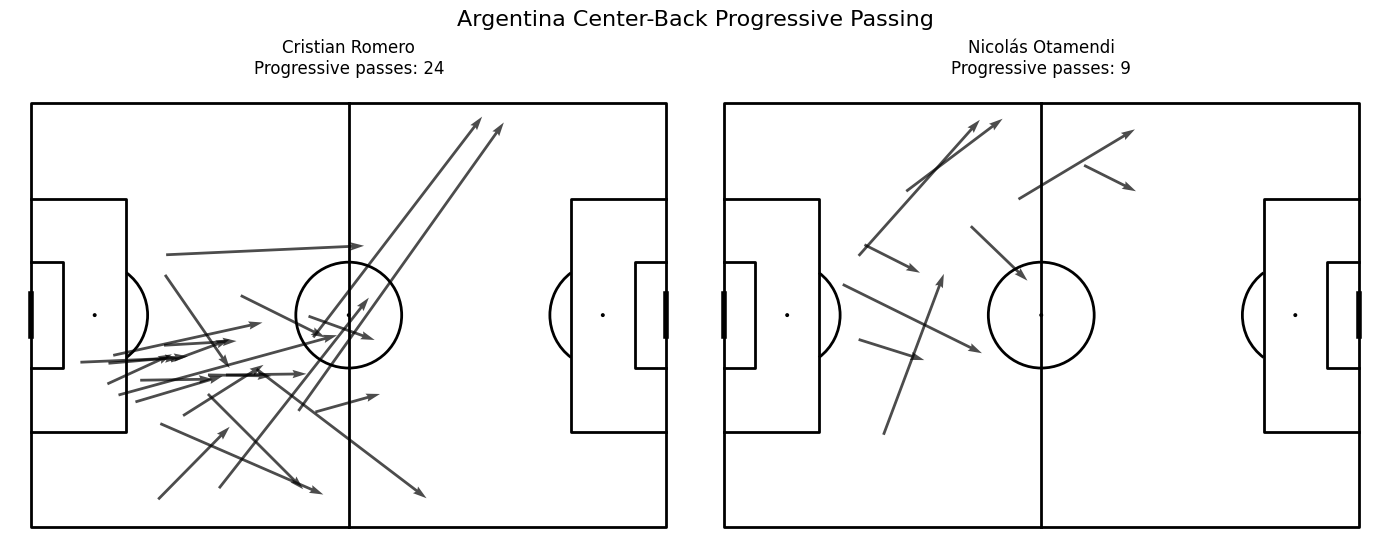

In [16]:
pitch = Pitch(
    pitch_type='statsbomb',
    line_color='black'
)

fig, axs = pitch.draw(
    nrows=1,
    ncols=2,
    figsize=(14, 6)
)

pitch.arrows(
    romero_progressive['x_start'],
    romero_progressive['y_start'],
    romero_progressive['x_end'],
    romero_progressive['y_end'],
    width=2,
    alpha=0.7,
    ax=axs[0]
)

pitch.arrows(
    otamendi_progressive['x_start'],
    otamendi_progressive['y_start'],
    otamendi_progressive['x_end'],
    otamendi_progressive['y_end'],
    width=2,
    alpha=0.7,
    ax=axs[1]
)

axs[0].set_title(
    f'Cristian Romero\nProgressive passes: {len(romero_progressive)}'
)

axs[1].set_title(
    f'Nicolás Otamendi\nProgressive passes: {len(otamendi_progressive)}'
)

fig.suptitle(
    'Argentina Center-Back Progressive Passing',
    fontsize=16
)

plt.tight_layout()
plt.show()

### Spatial differences between Romero and Otamendi

The progressive pass maps reveal different spatial patterns between Argentina's center-backs.

Cristian Romero showed a more vertical progression profile, frequently advancing the ball from the defensive line toward central areas around midfield. He also produced several switches of play, combining forward progression with changes of orientation.

Nicolás Otamendi's progressive passes were less frequent and tended to follow more lateral or diagonal trajectories.

Together with the previous passing metrics, this suggests that Romero played a more prominent role in advancing Argentina's possession from the back, while Otamendi contributed more through circulation and support.

# 3. Argentina's Progressive Passing Structure

After analyzing progression from the center-backs, the next step is to examine how progressive passes were distributed across the team.

This section focuses on:
- The most frequent progressive passing connections
- The players acting as key progression hubs
- The balance between generating and receiving progressive passes

In [17]:
progressive_connections_network = completed_passes_map.loc[
    (completed_passes_map['team'] == 'Argentina') &
    (completed_passes_map['is_progressive'] == True)]
progressive_connections_network = (progressive_connections_network
                          .groupby(['player', 'pass_recipient'])
                          .size()
                          .reset_index(name='progressive_passes')
                          .sort_values(by='progressive_passes', ascending=False))
progressive_connections_network.head(10)


,player,pass_recipient,progressive_passes
7,Cristian Gabriel Romero,Enzo Fernandez,9
12,Cristian Gabriel Romero,Rodrigo Javier De Paul,6
46,Nahuel Molina Lucero,Lionel Andrés Messi Cuccittini,6
48,Nicolás Alejandro Tagliafico,Alexis Mac Allister,6
37,Lionel Andrés Messi Cuccittini,Rodrigo Javier De Paul,4
34,Lionel Andrés Messi Cuccittini,Alexis Mac Allister,4
23,Enzo Fernandez,Lionel Andrés Messi Cuccittini,4
53,Nicolás Hernán Otamendi,Enzo Fernandez,4
47,Nahuel Molina Lucero,Rodrigo Javier De Paul,4
36,Lionel Andrés Messi Cuccittini,Julián Álvarez,3


In [18]:
arg_completed = completed_passes_map.loc[(completed_passes_map['team'] == 'Argentina')].copy()
player_positions = arg_completed.groupby('player').agg(
    avg_x = ('x_start', 'mean'),
    avg_y= ('y_start', 'mean'),
    completed_passes = ('x_start', 'count')
).reset_index()

player_positions = player_positions.sort_values(by='completed_passes', ascending=False)
player_positions.head(10)

,player,avg_x,avg_y,completed_passes
3,Enzo Fernandez,55.150633,43.230380,79
13,Nicolás Hernán Otamendi,38.540580,24.650725,69
1,Cristian Gabriel Romero,33.871667,52.686667,60
15,Rodrigo Javier De Paul,57.138596,58.984211,57
9,Lionel Andrés Messi Cuccittini,76.457143,49.675510,49
0,Alexis Mac Allister,68.148889,26.637778,45
12,Nicolás Alejandro Tagliafico,58.972727,7.643182,44
11,Nahuel Molina Lucero,57.297436,72.056410,39
6,Julián Álvarez,77.707692,34.746154,26
16,Ángel Fabián Di María Hernández,79.884000,11.448000,25


In [19]:
network_data = progressive_connections_network.merge(
    player_positions[['player', 'avg_x', 'avg_y']],
    on='player',
    how='left'
)

network_data = network_data.rename(columns={
    'avg_x': 'passer_x',
    'avg_y': 'passer_y'
})

recipient_positions = player_positions[
    ['player', 'avg_x', 'avg_y']
].copy()

recipient_positions = recipient_positions.rename(columns={
    'player': 'pass_recipient',
    'avg_x': 'recipient_x',
    'avg_y': 'recipient_y'
})

network_data = network_data.merge(
    recipient_positions,
    on='pass_recipient',
    how='left'
)

network_data.head(10)

,player,pass_recipient,progressive_passes,passer_x,passer_y,recipient_x,recipient_y
0,Cristian Gabriel Romero,Enzo Fernandez,9,33.871667,52.686667,55.150633,43.230380
1,Cristian Gabriel Romero,Rodrigo Javier De Paul,6,33.871667,52.686667,57.138596,58.984211
2,Nahuel Molina Lucero,Lionel Andrés Messi Cuccittini,6,57.297436,72.056410,76.457143,49.675510
3,Nicolás Alejandro Tagliafico,Alexis Mac Allister,6,58.972727,7.643182,68.148889,26.637778
4,Lionel Andrés Messi Cuccittini,Rodrigo Javier De Paul,4,76.457143,49.675510,57.138596,58.984211
5,Lionel Andrés Messi Cuccittini,Alexis Mac Allister,4,76.457143,49.675510,68.148889,26.637778
6,Enzo Fernandez,Lionel Andrés Messi Cuccittini,4,55.150633,43.230380,76.457143,49.675510
7,Nicolás Hernán Otamendi,Enzo Fernandez,4,38.540580,24.650725,55.150633,43.230380
8,Nahuel Molina Lucero,Rodrigo Javier De Paul,4,57.297436,72.056410,57.138596,58.984211
9,Lionel Andrés Messi Cuccittini,Julián Álvarez,3,76.457143,49.675510,77.707692,34.746154


In [20]:
network_edges = network_data.loc[
    network_data['progressive_passes'] >= 3
].copy()

network_players = pd.concat([
    network_edges['player'],
    network_edges['pass_recipient']
]).unique()

network_nodes = player_positions.loc[
    player_positions['player'].isin(network_players)
].copy()


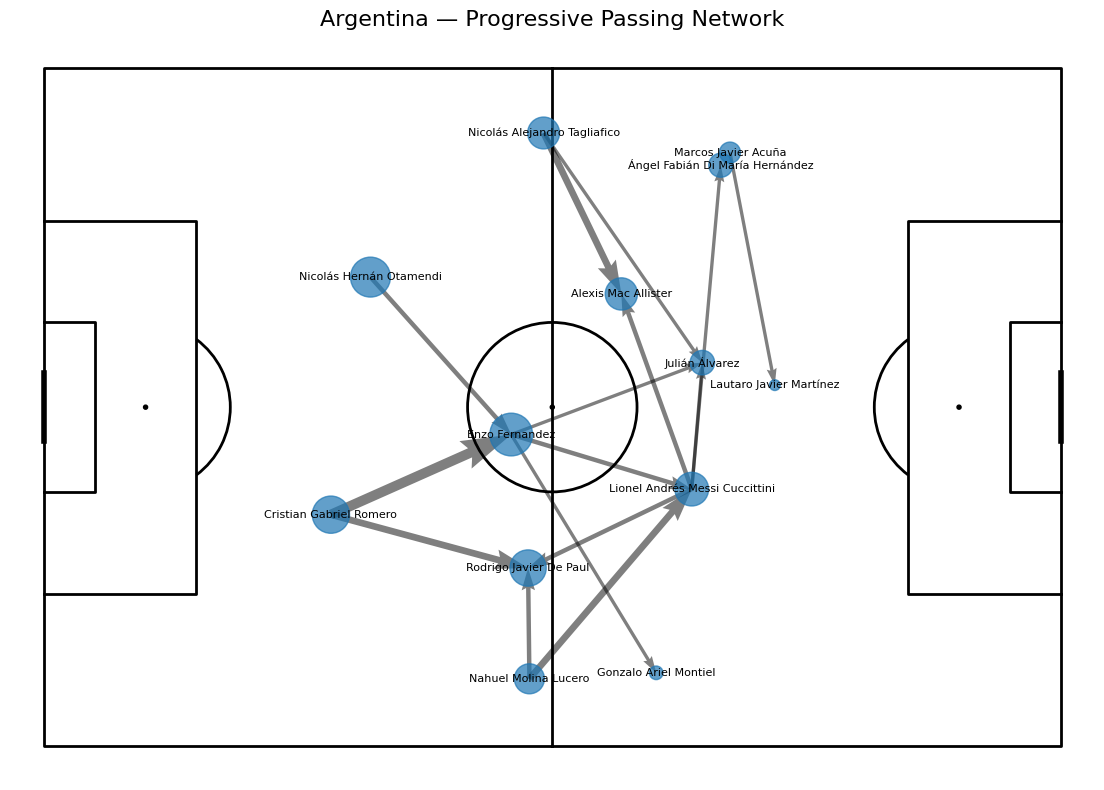

In [21]:
pitch = Pitch(
    pitch_type='statsbomb',
    line_color='black'
)

fig, ax = pitch.draw(figsize=(12, 8))

for _, row in network_edges.iterrows():

    pitch.arrows(
        row['passer_x'],
        row['passer_y'],
        row['recipient_x'],
        row['recipient_y'],
        width=row['progressive_passes'] * 0.8,
        alpha=0.5,
        ax=ax
    )

pitch.scatter(
    network_nodes['avg_x'],
    network_nodes['avg_y'],
    s=network_nodes['completed_passes'] * 12,
    alpha=0.7,
    ax=ax
)

for _, row in network_nodes.iterrows():

    ax.annotate(
        row['player'],
        (row['avg_x'], row['avg_y']),
        ha='center',
        va='center',
        fontsize=8
    )

ax.set_title(
    'Argentina — Progressive Passing Network',
    fontsize=16
)

plt.show()


### Progressive passing structure

Argentina's progressive passing network highlights Enzo Fernández and Lionel Messi
as two key hubs in the team's ball progression.

Enzo frequently received progressive passes from the center-backs, with the
Romero–Enzo connection being the most recurrent in the network. From a deeper
central position, he also connected progressively with several players further
up the pitch.

Messi showed a similar two-way role in more advanced areas, both receiving
progressive passes and generating progression toward teammates around him.

Julián Álvarez appeared primarily as a receiver of progressive passes in advanced
positions, reflecting a different role within Argentina's progression structure.

Overall, the network suggests that Enzo and Messi acted as important connecting
points between deeper ball progression and Argentina's attacking players.

In [22]:
arg_progressive = completed_passes_map.loc[
    (completed_passes_map['team'] == 'Argentina') &
    (completed_passes_map['is_progressive'] == True)
].copy()

progressive_passes_sent = (arg_progressive
                           .groupby('player')
                           .size()
                           .reset_index(name='progressive_sent'))
progressive_passes_received = (arg_progressive
                           .groupby('pass_recipient')
                           .size()
                           .reset_index(name='progressive_received'))
progressive_passes_received = progressive_passes_received.rename(columns={'pass_recipient': 'player'})

progressive_profile = progressive_passes_sent.merge(
    progressive_passes_received,
    on='player',
    how='outer'
)
progressive_profile = progressive_profile.fillna(0)
progressive_profile[
    ['progressive_sent', 'progressive_received']
] = progressive_profile[
    ['progressive_sent', 'progressive_received']
].astype(int)

progressive_profile = progressive_profile.sort_values(by='progressive_sent', ascending=False)
progressive_profile

,player,progressive_sent,progressive_received
1,Cristian Gabriel Romero,24,1
3,Enzo Fernandez,16,19
8,Lionel Andrés Messi Cuccittini,15,18
10,Nahuel Molina Lucero,14,2
11,Nicolás Alejandro Tagliafico,12,2
12,Nicolás Hernán Otamendi,9,2
2,Damián Emiliano Martínez,8,0
0,Alexis Mac Allister,7,17
9,Marcos Javier Acuña,6,6
14,Rodrigo Javier De Paul,5,16


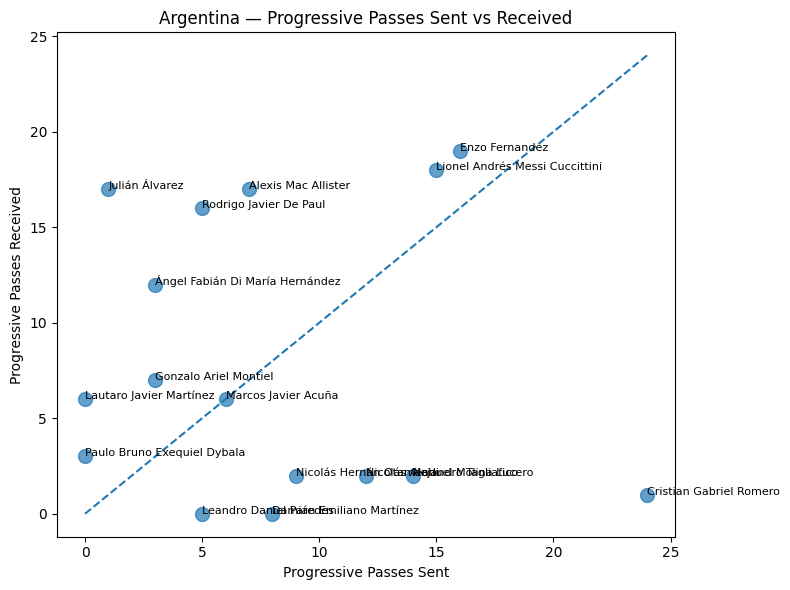

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    progressive_profile['progressive_sent'],
    progressive_profile['progressive_received'],
    s=100,
    alpha=0.7
)

max_value = max(
    progressive_profile['progressive_sent'].max(),
    progressive_profile['progressive_received'].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle='--'
)

for _, row in progressive_profile.iterrows():
    plt.annotate(
        row['player'],
        (
            row['progressive_sent'],
            row['progressive_received']
        ),
        fontsize=8
    )

plt.xlabel('Progressive Passes Sent')
plt.ylabel('Progressive Passes Received')
plt.title('Argentina — Progressive Passes Sent vs Received')

plt.tight_layout()
plt.show()

### Progressive pass generation vs reception

The sent-versus-received profile reinforces the roles observed in Argentina's
progressive passing network.

Enzo Fernández and Lionel Messi appear in the upper-right area of the chart,
showing high involvement both as generators and receivers of progressive passes.
Both lean slightly toward receiving progression, while remaining relatively
balanced compared with the rest of the team.

Cristian Romero represents the strongest progression-generating profile, sending
far more progressive passes than he received. Julián Álvarez shows the opposite
pattern, acting primarily as a receiver in advanced areas.

A broader positional pattern is also visible: deeper players generally generate
more progressive passes, while advanced players receive more. Part of this pattern
is influenced by the progressive-pass definition itself, as deeper players have
more distance available to reduce toward the opposition goal.

# 4. Final Third Entries

Progressive passes describe territorial advancement, but they do not necessarily
indicate whether the ball entered the final third.

To examine how Argentina accessed advanced areas, this section identifies completed
passes that started outside the final third and ended inside it.

In [24]:
completed_passes_map['enters_final_third'] = (
    (completed_passes_map['x_start'] < 80) &
    (completed_passes_map['x_end'] >= 80)
)

arg_final_third_entries = completed_passes_map.loc[
    (completed_passes_map['team'] == 'Argentina') &
    (completed_passes_map['enters_final_third'] == True)
].copy()

In [25]:
arg_final_third_entries['player'].value_counts()

,count
player,
Lionel Andrés Messi Cuccittini,7
Enzo Fernandez,7
Nahuel Molina Lucero,4
Cristian Gabriel Romero,3
Leandro Daniel Paredes,3
Marcos Javier Acuña,3
Rodrigo Javier De Paul,2
Ángel Fabián Di María Hernández,2
Nicolás Alejandro Tagliafico,2


In [26]:
arg_final_third_entries['pass_recipient'].value_counts()

,count
pass_recipient,
Lionel Andrés Messi Cuccittini,9
Ángel Fabián Di María Hernández,5
Alexis Mac Allister,5
Julián Álvarez,4
Marcos Javier Acuña,4
Lautaro Javier Martínez,3
Nahuel Molina Lucero,2
Gonzalo Ariel Montiel,2
Rodrigo Javier De Paul,1


### Who generates and receives final-third entries?

Messi and Enzo Fernández led Argentina in passes entering the final third, with
seven each. However, their roles differed considerably.

Messi was also the most frequent receiver of final-third entries, while Enzo
mainly acted as a generator from deeper positions.

The distribution of receivers suggests a strong involvement of wide and advanced
players, which can be examined more clearly through the spatial map below.

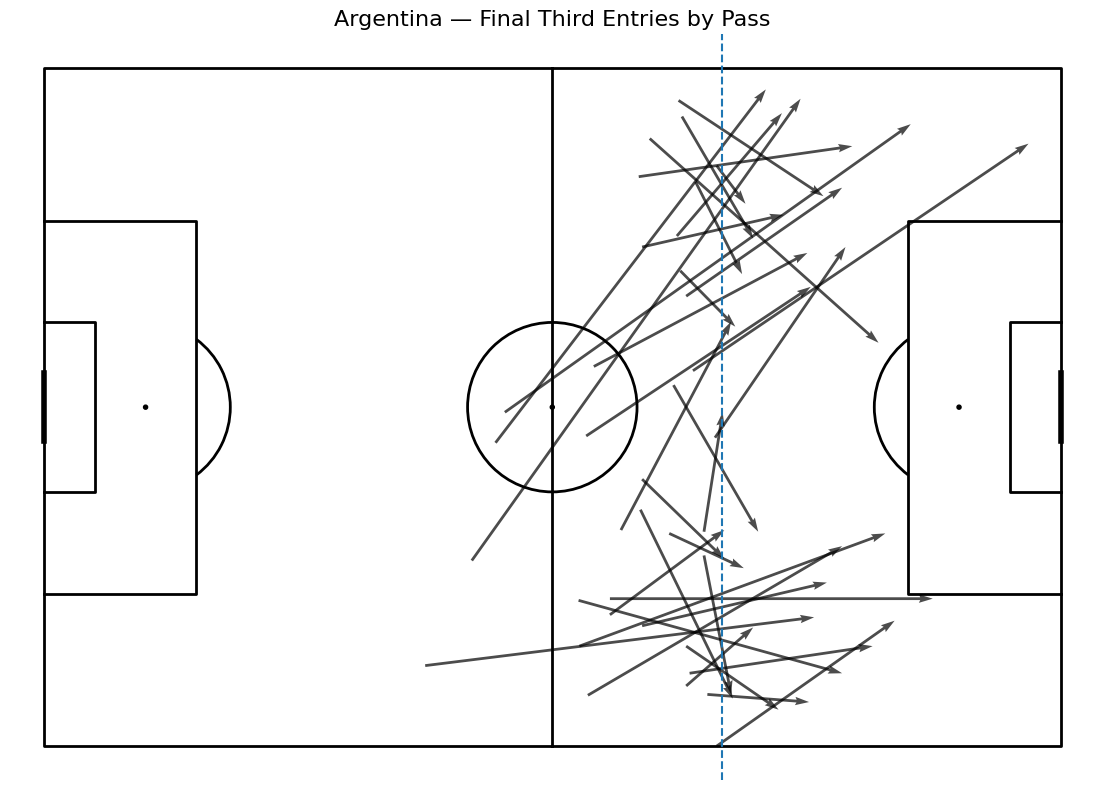

In [27]:
pitch = Pitch(
    pitch_type='statsbomb',
    line_color='black'
)

fig, ax = pitch.draw(figsize=(12, 8))

pitch.arrows(
    arg_final_third_entries['x_start'],
    arg_final_third_entries['y_start'],
    arg_final_third_entries['x_end'],
    arg_final_third_entries['y_end'],
    width=2,
    alpha=0.7,
    ax=ax
)

ax.axvline(
    x=80,
    linestyle='--',
    linewidth=1.5
)

ax.set_title(
    'Argentina — Final Third Entries by Pass',
    fontsize=16
)

plt.show()

### Spatial patterns of final-third entries

Argentina's final-third entries were heavily oriented toward the wide areas of the pitch.

Most completed passes entering the final third ended in the left or right channels, while relatively few targeted central areas directly.

Another clear pattern is that most of these entries originated in the opposition half, suggesting that Argentina typically established possession higher up the pitch before accessing the final third.

Overall, the spatial distribution indicates a strong reliance on wide channels to progress into advanced areas.

# 5. Chance Creation After Final-Third Entry

After identifying how Argentina entered the final third, the next step is to examine what happened after those entries.

This section measures how often possessions containing a final-third pass entry led to a shot, and compares the quality of those shots with Argentina's remaining non-penalty attempts.

In [28]:
arg_entry_possessions = arg_final_third_entries['possession'].unique()
len(arg_entry_possessions)

31

In [29]:
entries_per_possession = (
    arg_final_third_entries
    .groupby('possession')
    .size()
)

entries_per_possession.value_counts().sort_index()

,count
1,28
2,2
4,1


In [30]:
#Index of the first pass entering the final third in each possession
first_entry_by_possession = (
    arg_final_third_entries
    .groupby('possession')['index']
    .min()
    .reset_index(name='first_entry_index')
)
#dataframe with argentina shots
argentina_shots = match_shots.loc[
    match_shots['team'] == 'Argentina'
].copy()

shot_events = argentina_shots[
    ['possession', 'index']
].rename(columns={
    'index': 'shot_index'
})
#merge both tables
entry_shot_sequences = first_entry_by_possession.merge(
    shot_events,
    on='possession',
    how='inner'
)
#this will tell us if the shot came before the final third entry posession
entry_shot_sequences['shot_after_entry'] = (
    entry_shot_sequences['shot_index'] >
    entry_shot_sequences['first_entry_index']
)

entry_shot_sequences.head(15)

,possession,first_entry_index,shot_index,shot_after_entry
0,18,315,340,True
1,46,956,979,True
2,52,1174,1178,True
3,86,1865,1916,True
4,107,2198,2204,True
5,167,3040,3037,False
6,191,3380,3389,True
7,200,3513,3526,True
8,218,3905,3930,True
9,218,3905,3934,True


In [31]:
shots_after_entry = entry_shot_sequences.loc[
    entry_shot_sequences['shot_after_entry'] == True
].copy()

shots_after_entry['possession'].nunique()

11

In [32]:
len(shots_after_entry)

13

In [33]:
shot_possession_rate = (
    shots_after_entry['possession'].nunique()
    / len(arg_entry_possessions)
    * 100
)

shot_possession_rate

35.483870967741936

### From final-third entry to shot

Argentina recorded 31 possessions containing at least one completed pass into the
final third.

Of those possessions, 11 (35.5%) included at least one shot after the first
final-third pass entry, producing 13 shots in total.

This suggests that roughly one in three possessions with a pass entry into the
final third generated a subsequent shooting opportunity.

In [34]:
shots_with_xg = shots_after_entry.merge(
    argentina_shots[['index','shot_statsbomb_xg', 'shot_type', 'shot_outcome', 'location']],
    left_on='shot_index',
    right_on='index',
    how='left')

shots_with_xg

,possession,first_entry_index,shot_index,shot_after_entry,index,shot_statsbomb_xg,shot_type,shot_outcome,location
0,18,315,340,True,340,0.062813,Open Play,Blocked,"[99.2, 47.9]"
1,46,956,979,True,979,0.010578,Open Play,Wayward,"[94.3, 23.5]"
2,52,1174,1178,True,1178,0.303409,Open Play,Goal,"[111.8, 32.1]"
3,86,1865,1916,True,1916,0.040216,Open Play,Saved,"[103.3, 52.3]"
4,107,2198,2204,True,2204,0.059534,Open Play,Saved,"[110.5, 24.9]"
5,191,3380,3389,True,3389,0.043032,Open Play,Saved,"[96.2, 40.9]"
6,200,3513,3526,True,3526,0.019259,Open Play,Off T,"[98.2, 23.8]"
7,218,3905,3930,True,3930,0.232606,Open Play,Blocked,"[108.8, 45.3]"
8,218,3905,3934,True,3934,0.020604,Open Play,Blocked,"[96.3, 49.4]"
9,221,3966,3970,True,3970,0.140292,Open Play,Off T,"[105.1, 33.5]"


In [35]:
shot_indexes_after_entry = shots_with_xg['shot_index'].unique()
other_non_penalty_shots = argentina_shots.loc[
    (~argentina_shots['index'].isin(shot_indexes_after_entry)) &
    (argentina_shots['shot_type'] != 'Penalty')
].copy()

other_shots_npxg_total = other_non_penalty_shots['shot_statsbomb_xg'].sum()
after_pass_npxg_total= shots_with_xg['shot_statsbomb_xg'].sum()

total_shots_npxg = other_shots_npxg_total+after_pass_npxg_total
total_shots_npxg

#create a dataframe combining both shot type dataframes

pd.DataFrame({
    'group':[
        'After Final Third Pass Entry',
        'Other Arg Shots'
    ],
    'Shots':[
        len(shot_indexes_after_entry),
        len(other_non_penalty_shots)],
    'Share Shots':[
        (len(shot_indexes_after_entry) / (len(shot_indexes_after_entry)+len(other_non_penalty_shots))) * 100,
        (len(other_non_penalty_shots) / (len(shot_indexes_after_entry)+len(other_non_penalty_shots))) * 100],
    'Total npxg ':[
        shots_with_xg['shot_statsbomb_xg'].sum(),
        other_non_penalty_shots['shot_statsbomb_xg'].sum()],
      'Share npxg':[
        (after_pass_npxg_total/total_shots_npxg)*100,
        (other_shots_npxg_total/total_shots_npxg)*100],
    'Mean npxg per Shot':[
        (shots_with_xg['shot_statsbomb_xg']).mean(),
        (other_non_penalty_shots['shot_statsbomb_xg']).mean()]

})

,group,Shots,Share Shots,Total npxg,Share npxg,Mean npxg per Shot
0,After Final Third Pass Entry,13,68.421053,1.631369,82.609091,0.125490
1,Other Arg Shots,6,31.578947,0.343437,17.390909,0.057239


### Chance quality after final-third entries

Shots following a completed pass into the final third accounted for 68.4% of
Argentina's non-penalty attempts, but generated 82.6% of the team's total npxG.

These shots also produced a considerably higher average npxG per attempt
(0.125 vs 0.057).

This indicates that possessions containing a pass entry into the final third were
associated not only with greater shot volume, but also with higher-quality chances
in this match.

In [36]:
after_entry_plot = shots_with_xg.copy()

after_entry_plot['x'] = after_entry_plot['location'].apply(lambda loc: loc[0])
after_entry_plot['y'] = after_entry_plot['location'].apply(lambda loc: loc[1])
after_entry_plot['is_goal'] = after_entry_plot['shot_outcome'] == 'Goal'


other_shots_plot = other_non_penalty_shots.copy()

other_shots_plot['x'] = other_shots_plot['location'].apply(lambda loc: loc[0])
other_shots_plot['y'] = other_shots_plot['location'].apply(lambda loc: loc[1])
other_shots_plot['is_goal'] = other_shots_plot['shot_outcome'] == 'Goal'

after_goals = after_entry_plot.loc[after_entry_plot['is_goal']]
after_no_goals = after_entry_plot.loc[~after_entry_plot['is_goal']]

other_goals = other_shots_plot.loc[other_shots_plot['is_goal']]
other_no_goals = other_shots_plot.loc[~other_shots_plot['is_goal']]

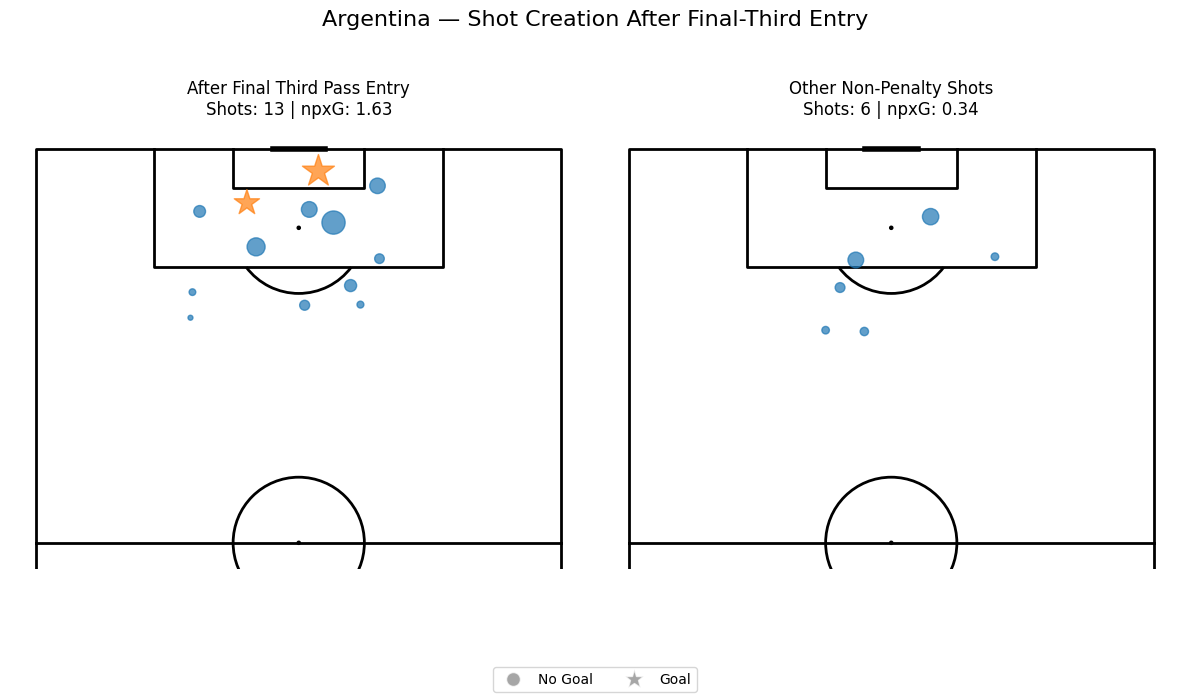

In [37]:
pitch = VerticalPitch(
    pitch_type='statsbomb',
    half=True,
    line_color='black'
)

fig, axs = pitch.draw(
    nrows=1,
    ncols=2,
    figsize=(12, 7)
)

# After Final Third Pass Entry

pitch.scatter(
    after_no_goals['x'],
    after_no_goals['y'],
    s=after_no_goals['shot_statsbomb_xg'] * 1200,
    alpha=0.7,
    ax=axs[0]
)

pitch.scatter(
    after_goals['x'],
    after_goals['y'],
    s=after_goals['shot_statsbomb_xg'] * 1200,
    marker='*',
    alpha=0.7,
    ax=axs[0]
)


# Other Argentina Shots

pitch.scatter(
    other_no_goals['x'],
    other_no_goals['y'],
    s=other_no_goals['shot_statsbomb_xg'] * 1200,
    alpha=0.7,
    ax=axs[1]
)

pitch.scatter(
    other_goals['x'],
    other_goals['y'],
    s=other_goals['shot_statsbomb_xg'] * 1200,
    marker='*',
    alpha=0.7,
    ax=axs[1]
)

axs[0].set_title(
    'After Final Third Pass Entry\n'
    f'Shots: {len(after_entry_plot)} | npxG: {after_entry_plot["shot_statsbomb_xg"].sum():.2f}'
)

axs[1].set_title(
    'Other Non-Penalty Shots\n'
    f'Shots: {len(other_shots_plot)} | npxG: {other_shots_plot["shot_statsbomb_xg"].sum():.2f}'
)

fig.suptitle(
    'Argentina — Shot Creation After Final-Third Entry',
    fontsize=16
)

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='No Goal',
        markerfacecolor='gray',
        markersize=10,
        alpha=0.7
    ),
    Line2D(
        [0], [0],
        marker='*',
        color='w',
        label='Goal',
        markerfacecolor='gray',
        markersize=14,
        alpha=0.7
    )
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=2
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

### Shot creation after final-third entry

The shot map reinforces the difference between both groups.

Shots following a completed pass into the final third were more frequent and
accounted for a substantially larger share of Argentina's non-penalty xG.

Although both groups include attempts from relatively dangerous areas, the
post-entry group produced a greater concentration of higher-value chances.

This suggests that final-third pass entries were an important part of Argentina's
chance-creation process in this match.

# 6. Conclusions

This analysis highlights several patterns in how Argentina progressed the ball and created chances against France in the 2022 FIFA World Cup Final.

- **Argentina generated a higher attacking output**, producing more shots and more non-penalty xG than France across the match.

- **Cristian Romero played a particularly important role in progression from the defensive line.** Despite Nicolás Otamendi completing more passes overall, Romero completed considerably more progressive passes and showed a more vertical progression profile, including several switches of play.

- **Enzo Fernández and Lionel Messi emerged as the main progressive passing hubs.** Both players combined high volumes of progressive passes received and sent, acting as key connecting points between deeper build-up and more advanced attacking areas.

- **Argentina accessed the final third predominantly through wide areas.** Most completed passes entering the final third ended in the left or right channels, while relatively few targeted central areas directly. Most of these entries also originated in the opposition half.

- **Final-third pass entries were strongly associated with chance creation.** Possessions containing a final-third pass entry produced 13 subsequent shots across 11 possessions. These attempts accounted for 68.4% of Argentina's non-penalty shots but 82.6% of its total npxG, indicating both higher shot volume and higher average chance quality.

Overall, Argentina's attacking progression in this match was structured around ball advancement from the back, central progression through key connectors such as Enzo Fernández and Lionel Messi, frequent access to the final third through wide areas, and a strong relationship between final-third pass entries and the creation of higher-value shooting opportunities.

## Limitations

This analysis is based on a single match and should not be interpreted as a general description of Argentina's tactical identity.

The definition of a progressive pass used in this project — a reduction of at least 10 units in distance to the opposition goal — is a simplified analytical choice and may favor players operating from deeper positions.

Similarly, a final-third pass entry identifies only completed passes crossing the x = 80 threshold and does not capture other forms of progression such as carries, recoveries, throw-ins, or possessions that begin inside the final third.